
# DeepSeek-Foundations · Workbook 06
### Neural Networks — the function that learns: backprop, initialization, regularization

**Series:** DeepSeek-Foundations v1.0 · **Runtime:** ~90 min · **Prereqs:** [Workbook 02 — Calculus & Autodiff](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/02_Calculus_and_Autodiff.ipynb), [Workbook 05 — Optimization](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/05_Optimization.ipynb)

> **Abstract.** We present the multilayer perceptron (MLP) as the canonical learnable function: a composition of affine maps and fixed nonlinearities, parameterized by weight matrices and bias vectors. We establish the forward pass and the non-negotiability of nonlinearity — a stack of linear layers is exactly one linear layer — then demonstrate empirically that a two-layer network with 50 hidden units fits $\sin$ on a compact interval to a mean squared error more than 30x below the best linear fit, which is the universal approximation theorem in action, caveats included. We derive the backward pass by hand for a two-layer network and verify every gradient numerically against central finite differences. We then study how the initialization scale controls activation variance across 20 layers — vanishing, exploding, and He-stable regimes — and close with weight decay as the mechanism that trades a memorized training set for a generalizing one. All experiments are pure NumPy on a CPU runtime.

**How this fits the series:** [Workbook 02](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/02_Calculus_and_Autodiff.ipynb) supplied the chain rule; [Workbook 05](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/05_Optimization.ipynb) supplied the optimizers that consume gradients. This workbook assembles those pieces into the first trainable network — the exact object a transformer stacks, and the object [Workbook 07 — The Transformer](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/07_Transformers.ipynb) builds on next.

- **Workbook:** [06 — Neural Networks](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/06_Neural_Networks.ipynb)
- **Master report:** [00 — DeepSeek-Foundations](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb)



## 1. The perceptron and the MLP

**The perceptron** is a single affine map followed by a decision rule. With weight vector $w \in \mathbb{R}^d$ and bias $b \in \mathbb{R}$,

$$ z = w^\top x + b = \sum_{i=1}^{d} w_i x_i + b, \qquad \hat{y} = \sigma(z), $$

where $\sigma$ is a fixed nonlinearity. The perceptron separates points by a hyperplane — it is a *linear classifier*, and any problem needing a curved decision boundary is out of reach no matter how $w$ and $b$ are tuned.

**The multilayer perceptron (MLP)** removes that ceiling by composing layers. With input $x \in \mathbb{R}^{d_0}$, hidden weight $W_1 \in \mathbb{R}^{d_0 \times d_1}$, hidden bias $b_1$, output weight $W_2 \in \mathbb{R}^{d_1 \times d_2}$ and output bias $b_2$:

$$ h = \sigma(x W_1 + b_1), \qquad \hat{y} = h W_2 + b_2, $$

where $\sigma$ is applied elementwise. Each hidden unit $h_j = \sigma\big(\sum_i x_i (W_1)_{ij} + (b_1)_j\big)$ computes a nonlinear feature of the input; the output layer recombines features into predictions (with a softmax on top for classification, Section 2).

Two facts matter from the start. **First**, the composition is expressive only because of $\sigma$ — without it, two layers collapse into one (Section 2). **Second**, the only learnable objects are $W_1, b_1, W_2, b_2$; their count is the parameter count, and every later section is about how those parameters are set. The demo builds a small MLP forward pass and counts what is learnable.


In [1]:

import numpy as np

rng = np.random.default_rng(42)

# Tiny MLP: 4 inputs -> 8 hidden (ReLU) -> 3 logits
n_in, n_hid, n_out = 4, 8, 3
W1 = rng.normal(size=(n_in, n_hid)) * 0.5
b1 = np.zeros(n_hid)
W2 = rng.normal(size=(n_hid, n_out)) * 0.5
b2 = np.zeros(n_out)

def relu(x):
    return np.maximum(x, 0.0)

x = np.array([0.5, -1.2, 2.1, 0.3])

h_pre = x @ W1 + b1        # affine map (layer 1)
h = relu(h_pre)            # nonlinearity: the reason depth works
logits = h @ W2 + b2       # affine map (layer 2)

print("input           :", x)
print("pre-activation  :", np.round(h_pre, 3))
print("hidden (ReLU)   :", np.round(h, 3))
print("logits          :", np.round(logits, 3))
n_params = W1.size + b1.size + W2.size + b2.size
print("parameter count :", n_params, "=", W1.size, "+", b1.size, "+", W2.size, "+", b2.size)


input           : [ 0.5 -1.2  2.1  0.3]
pre-activation  : [ 0.409 -0.808  0.662 -0.229 -0.66  -1.652  1.356  0.213]
hidden (ReLU)   : [0.409 0.    0.662 0.    0.    0.    1.356 0.213]
logits          : [-0.216  0.427 -0.684]
parameter count : 67 = 32 + 8 + 24 + 3



## 2. Activation functions

An activation function $\sigma: \mathbb{R} \to \mathbb{R}$ is applied elementwise after every affine map except the last (which stays linear for regression, or passes through softmax for classification). The four workhorses:

| Activation | Definition | Derivative |
|---|---|---|
| Sigmoid | $\sigma(x) = \dfrac{1}{1 + e^{-x}}$ | $\sigma'(x) = \sigma(x)\big(1 - \sigma(x)\big)$ |
| Tanh | $\tanh(x) = \dfrac{e^x - e^{-x}}{e^x + e^{-x}}$ | $\tanh'(x) = 1 - \tanh^2(x)$ |
| ReLU | $\max(0, x)$ | $1$ if $x > 0$, else $0$ (subgradient at $0$) |
| GELU | $x\,\Phi(x) \approx x\,\sigma(1.702\,x)$ | product rule on the approximation |

**Softmax** is the multi-class output nonlinearity, mapping logits $z \in \mathbb{R}^K$ to a probability vector:

$$ p_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}, \qquad \frac{\partial p_i}{\partial z_j} = p_i\,(\delta_{ij} - p_j). $$

The Jacobian identity becomes the cross-entropy gradient in Workbook 07, so it is worth verifying numerically below.

**Why nonlinearity is non-negotiable.** The composition of two affine maps is affine:

$$ (x W_1 + b_1) W_2 + b_2 = x\,(W_1 W_2) + (b_1 W_2 + b_2), $$

so a deep *linear* network is exactly one linear layer with effective weight $W_1 W_2$. Depth buys nothing without nonlinearities — the demo shows the collapse numerically.


In [2]:

import numpy as np

xs = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])

def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def tanh(x):    return np.tanh(x)
def relu(x):    return np.maximum(x, 0.0)
def gelu(x):    return x * sigmoid(1.702 * x)   # smooth tanh-approx of GELU

def d_sigmoid(x):
    s = sigmoid(x); return s * (1.0 - s)
def d_tanh(x):
    t = tanh(x); return 1.0 - t ** 2
def d_relu(x):
    return (x > 0).astype(float)
def d_gelu(x):
    # product rule on x * sigmoid(1.702 x)
    g = sigmoid(1.702 * x)
    return g + x * 1.702 * g * (1.0 - g)

print("activation / derivative at x =", xs)
for name, f, df in [("sigmoid", sigmoid, d_sigmoid), ("tanh", tanh, d_tanh),
                    ("ReLU", relu, d_relu), ("GELU", gelu, d_gelu)]:
    print(f"{name:8s}  f : {np.round(f(xs), 4)}")
    print(f"{'':8s}  f': {np.round(df(xs), 4)}")

# softmax: logits -> probabilities
z = np.array([2.0, 1.0, 0.1])
p = np.exp(z - z.max()); p = p / p.sum()
print("softmax([2.0, 1.0, 0.1]) =", np.round(p, 4), " sums to", round(p.sum(), 6))
J = p[:, None] * (np.eye(3) - p[None, :])        # Jacobian p_i (delta_ij - p_j)
print("Jacobian row 0        =", np.round(J[0], 4))

# --- linear collapse: two stacked linear layers = one linear layer ---
rng = np.random.default_rng(0)
A = rng.normal(size=(3, 5)); B = rng.normal(size=(5, 2))
v = rng.normal(size=3)
composed = (v @ A) @ B          # apply A, then B
single   = v @ (A @ B)          # merge into one matrix first
print("max |composed - single| =", np.abs(composed - single).max())
print("=> stacking linear layers without nonlinearity buys NOTHING;")
print("   the pair is still one affine map.")


activation / derivative at x = [-2.  -0.5  0.   0.5  2. ]
sigmoid   f : [0.1192 0.3775 0.5    0.6225 0.8808]
          f': [0.105 0.235 0.25  0.235 0.105]
tanh      f : [-0.964  -0.4621  0.      0.4621  0.964 ]
          f': [0.0707 0.7864 1.     0.7864 0.0707]
ReLU      f : [0.  0.  0.  0.5 2. ]
          f': [0. 0. 0. 1. 1.]
GELU      f : [-0.0643 -0.1496  0.      0.3504  1.9357]
          f': [-0.0738  0.1208  0.5     0.8792  1.0738]
softmax([2.0, 1.0, 0.1]) = [0.659  0.2424 0.0986]  sums to 1.0
Jacobian row 0        = [ 0.2247 -0.1598 -0.065 ]
max |composed - single| = 1.1102230246251565e-16
=> stacking linear layers without nonlinearity buys NOTHING;
   the pair is still one affine map.



## 3. Universal approximation

**Theorem (informal).** Let $f: K \to \mathbb{R}$ be continuous on a compact set $K \subset \mathbb{R}^d$, and let $\epsilon > 0$. Then there exists a two-layer network with $N$ hidden units and any non-polynomial activation $\sigma$ whose output $\hat{f}$ satisfies

$$ \sup_{x \in K} \left|\hat{f}(x) - f(x)\right| < \epsilon. $$

**Intuition: bump functions.** A hidden unit computes $\sigma(w_j^\top x + b_j)$. With sigmoid or tanh, taking $\|w_j\|$ large and tuning $b_j$ localizes the unit into a *bump* — near a constant inside a small region, near zero outside. A weighted sum of enough bumps tiles $K$ and matches $f$ to any tolerance, the way a histogram refined until it tracks a curve.

**What the theorem does NOT say** (the honest part):

1. It does not bound $N$ — the required width can be astronomically large; this is an existence claim, not a practical recipe.
2. It says nothing about *learning*: gradient descent may never find the good weights in a non-convex landscape.
3. It says nothing about *data*: approximating $f$ is not the same as estimating it from finitely many noisy samples.
4. It is a statement on $K$ only: outside the compact domain the network may do anything.

The demo trains a 50-hidden-unit network on $\sin$ over $[-3, 3]$ with plain gradient descent (manual backprop, NumPy only) and compares against the best linear fit.


NN MSE  (50 hidden, tanh) : 0.005177
linear baseline MSE       : 0.167995
NN beats linear by        : 32.4x


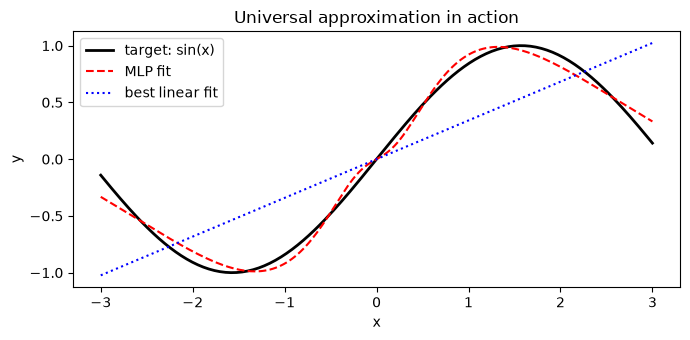

In [3]:

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# dense samples of sin on [-3, 3]
xs = np.linspace(-3.0, 3.0, 200)
ys = np.sin(xs)

# 1 -> 50 -> 1 MLP, tanh hidden, linear output, He-ish init
n_h = 50
W1 = rng.normal(size=(1, n_h)) * np.sqrt(2.0)
b1 = np.zeros(n_h)
W2 = rng.normal(size=(n_h, 1)) * np.sqrt(2.0 / n_h)
b2 = np.zeros(1)

lr = 0.01
for it in range(6000):
    h = np.tanh(xs[:, None] @ W1 + b1)                 # (N, n_h)
    pred = h @ W2 + b2                                 # (N, 1)
    d = 2.0 * (pred - ys[:, None]) / len(xs)           # dL/dlogits
    W2 -= lr * (h.T @ d); b2 -= lr * d.sum(axis=0)
    dh = (d @ W2.T) * (1.0 - h ** 2)                   # tanh' chain rule
    W1 -= lr * (xs[:, None].T @ dh); b1 -= lr * dh.sum(axis=0)

h = np.tanh(xs[:, None] @ W1 + b1)
pred = (h @ W2 + b2)[:, 0]
mse_nn = ((pred - ys) ** 2).mean()

# baseline: best linear fit (least squares)
A = np.stack([np.ones_like(xs), xs], axis=1)
coef, *_ = np.linalg.lstsq(A, ys, rcond=None)
lin = A @ coef
mse_lin = ((lin - ys) ** 2).mean()

print(f"NN MSE  (50 hidden, tanh) : {mse_nn:.6f}")
print(f"linear baseline MSE       : {mse_lin:.6f}")
print(f"NN beats linear by        : {mse_lin / mse_nn:.1f}x")

plt.figure(figsize=(7, 3.5))
plt.plot(xs, ys, "k-", lw=2, label="target: sin(x)")
plt.plot(xs, pred, "r--", lw=1.5, label="MLP fit")
plt.plot(xs, lin, "b:", lw=1.5, label="best linear fit")
plt.legend(); plt.xlabel("x"); plt.ylabel("y")
plt.title("Universal approximation in action")
plt.tight_layout(); plt.show()



## 4. Backprop by hand

Backpropagation is the chain rule applied once per layer, in reverse order. Consider a two-layer ReLU network with squared loss on a single example $x \in \mathbb{R}^{d}$, target $y \in \mathbb{R}^{k}$:

$$ h = \mathrm{ReLU}(x W_1 + b_1), \qquad \hat{y} = h W_2 + b_2, \qquad \mathcal{L} = \tfrac{1}{2}\|\hat{y} - y\|^2. $$

**Forward pass** records $h$ and the pre-activations. **Backward pass** walks the chain rule from the loss back to the parameters:

$$ \frac{\partial \mathcal{L}}{\partial \hat{y}} = \hat{y} - y, \qquad \frac{\partial \mathcal{L}}{\partial W_2} = h^\top \frac{\partial \mathcal{L}}{\partial \hat{y}}, \qquad \frac{\partial \mathcal{L}}{\partial b_2} = \frac{\partial \mathcal{L}}{\partial \hat{y}}, $$

$$ \frac{\partial \mathcal{L}}{\partial h} = \frac{\partial \mathcal{L}}{\partial \hat{y}} W_2^\top, \qquad \frac{\partial \mathcal{L}}{\partial (x W_1 + b_1)} = \frac{\partial \mathcal{L}}{\partial h} \odot \mathrm{ReLU}'(x W_1 + b_1), $$

$$ \frac{\partial \mathcal{L}}{\partial W_1} = x^\top \frac{\partial \mathcal{L}}{\partial (x W_1 + b_1)}, \qquad \frac{\partial \mathcal{L}}{\partial b_1} = \frac{\partial \mathcal{L}}{\partial (x W_1 + b_1)}. $$

The pattern generalizes to any depth: each layer receives $\delta = \partial \mathcal{L}/\partial(\text{its output})$, converts it into weight and bias gradients, and passes $\delta$ back through the transposed weight. The demo implements this by hand and verifies every parameter class against central finite differences:

$$ \frac{\partial \mathcal{L}}{\partial \theta_i} \approx \frac{\mathcal{L}(\theta + \epsilon e_i) - \mathcal{L}(\theta - \epsilon e_i)}{2\epsilon}, \qquad \epsilon = 10^{-6}. $$


In [4]:

import numpy as np

rng = np.random.default_rng(1)
n_in, n_h, n_out = 3, 4, 2
x = rng.normal(size=n_in)
y = rng.normal(size=n_out)
W1 = rng.normal(size=(n_in, n_h)) * 0.5
b1 = np.zeros(n_h)
W2 = rng.normal(size=(n_h, n_out)) * 0.5
b2 = np.zeros(n_out)

def relu(z): return np.maximum(z, 0.0)

def forward(x, W1, b1, W2, b2):
    h_pre = x @ W1 + b1
    h = relu(h_pre)
    logits = h @ W2 + b2
    return h_pre, h, logits

def loss(logits, y):
    return 0.5 * ((logits - y) ** 2).sum()

# ---- manual backward pass (derived in the markdown above) ----
h_pre, h, logits = forward(x, W1, b1, W2, b2)
dL_dlogits = logits - y                        # dL/dyhat = yhat - y
dL_dW2 = np.outer(h, dL_dlogits)               # h^T (dL/dlogits)
dL_db2 = dL_dlogits
dL_dh = dL_dlogits @ W2.T
dL_dh_pre = dL_dh * (h_pre > 0)                # ReLU' mask
dL_dW1 = np.outer(x, dL_dh_pre)
dL_db1 = dL_dh_pre

# ---- numerical check: central finite differences ----
n1, nh, no = n_in * n_h, n_h, n_h * n_out

def pack(W1, b1, W2, b2):
    return np.concatenate([W1.ravel(), b1, W2.ravel(), b2])

def unpack(theta):
    W1 = theta[:n1].reshape(n_in, n_h)
    b1 = theta[n1:n1 + nh]
    W2 = theta[n1 + nh:n1 + nh + no].reshape(n_h, n_out)
    b2 = theta[n1 + nh + no:]
    return W1, b1, W2, b2

def loss_at(theta):
    W1, b1, W2, b2 = unpack(theta)
    _, _, logits = forward(x, W1, b1, W2, b2)
    return loss(logits, y)

theta0 = pack(W1, b1, W2, b2)
eps = 1e-6
num = np.zeros_like(theta0)
for i in range(theta0.size):
    tp = theta0.copy(); tp[i] += eps
    tm = theta0.copy(); tm[i] -= eps
    num[i] = (loss_at(tp) - loss_at(tm)) / (2.0 * eps)

ana = pack(dL_dW1, dL_db1, dL_dW2, dL_db2)
print("max |analytic - numerical| =", np.abs(ana - num).max())
print("W1 OK:", np.allclose(dL_dW1, num[:n1].reshape(n_in, n_h), atol=1e-4))
print("b1 OK:", np.allclose(dL_db1, num[n1:n1 + nh], atol=1e-4))
print("W2 OK:", np.allclose(dL_dW2, num[n1 + nh:n1 + nh + no].reshape(n_h, n_out), atol=1e-4))
print("b2 OK:", np.allclose(dL_db2, num[n1 + nh + no:], atol=1e-4))
print("=> manual backward pass matches finite differences for every parameter class")


max |analytic - numerical| = 1.6034023414546184e-10
W1 OK: True
b1 OK: True
W2 OK: True
b2 OK: True
=> manual backward pass matches finite differences for every parameter class



## 5. Initialization

The forward pass of Section 1 and the gradients of Section 4 both depend on where the parameters *start*. Three failure modes matter.

**Zeros fail by symmetry.** If every weight in a layer starts equal (all zeros, or any constant), every hidden unit computes identical activations and receives identical gradients forever, so units stay identical and the layer can never specialize. Randomness breaks the tie.

**Scale controls variance.** For a linear layer $h = x W$ with $x \in \mathbb{R}^{n}$, $\mathrm{Var}(x_i) = \mathrm{Var}(x)$ and i.i.d. weights $W_{ij} \sim \mathcal{N}(0, \sigma^2)$:

$$ \mathrm{Var}(h_j) = \sum_{i=1}^{n} \mathrm{Var}(x_i)\, \mathrm{Var}(W_{ij}) = n\, \sigma^2\, \mathrm{Var}(x). $$

Across $L$ layers the variance multiplies by $(n \sigma^2)^L$. If $\sigma$ is too small the signal vanishes (activations and gradients $\to 0$); if too large it explodes — or, with tanh, saturates into flat regions where gradients vanish. The variance-preserving scale for a linear layer is $\sigma = 1/\sqrt{n}$ (Xavier); for ReLU, half the units die on average, so the correct scale is $\sigma = \sqrt{2/n}$ (He). The demo pushes activations through 20 random layers at four scales, with and without tanh, and measures what survives to layer 20.


In [5]:

import numpy as np

rng = np.random.default_rng(3)
width, depth = 100, 20
sigmas = [0.01, 0.2, 1.0, np.sqrt(2.0 / width)]   # sqrt(2/n) = He scale

def linear_stack(sigma):
    x = rng.normal(size=width)
    for _ in range(depth):
        W = rng.normal(size=(width, width)) * sigma
        x = x @ W
    return x.std()

def tanh_stack(sigma):
    x = rng.normal(size=width)
    for _ in range(depth):
        W = rng.normal(size=(width, width)) * sigma
        x = np.tanh(x @ W)
    return x.std()

print("std of activations after", depth, "layers (input std = 1)")
print("  sigma       linear stack   tanh stack")
for s in sigmas:
    print(f"  {s:7.4f}     {linear_stack(s):12.4g}   {tanh_stack(s):10.4g}")

print()
print("Linear: variance multiplies by (n*sigma^2) per layer.")
print("  0.01  -> (0.1)^20  ~ 1e-20 : vanishing")
print("  0.2   -> 2^20      ~ 1e6   : exploding")
print("  1.0   -> 10^20     ~ 1e20  : exploding")
print("  sqrt(2/n)=0.141 -> (sqrt 2)^20 ~ 1e3 : still grows -- the exact")
print("  neutral scale for a LINEAR layer is 1/sqrt(n) = 0.1 (Xavier).")
print()
print("Tanh clips runaway growth into saturation (std ~ 0.7-1.0, gradients")
print("~ 0), so the He scale keeps activations at healthy order-1 std.")


std of activations after 20 layers (input std = 1)
  sigma       linear stack   tanh stack
   0.0100        7.532e-21    8.741e-21
   0.2000        1.333e+06       0.6443
   1.0000        9.002e+19       0.9587
   0.1414            881.1       0.5004

Linear: variance multiplies by (n*sigma^2) per layer.
  0.01  -> (0.1)^20  ~ 1e-20 : vanishing
  0.2   -> 2^20      ~ 1e6   : exploding
  1.0   -> 10^20     ~ 1e20  : exploding
  sqrt(2/n)=0.141 -> (sqrt 2)^20 ~ 1e3 : still grows -- the exact
  neutral scale for a LINEAR layer is 1/sqrt(n) = 0.1 (Xavier).

Tanh clips runaway growth into saturation (std ~ 0.7-1.0, gradients
~ 0), so the He scale keeps activations at healthy order-1 std.



## 6. Regularization: closing the train–test gap

A network with enough parameters can drive training error toward zero by memorizing noise — but memorization does not transfer. The **generalization gap** $\mathcal{L}_{\text{test}} - \mathcal{L}_{\text{train}}$ grows with capacity and training time, and regularization keeps it in check.

**Weight decay (L2).** Add a penalty on the squared Frobenius norm of the weights:

$$ \tilde{\mathcal{L}} = \mathcal{L} + \frac{\lambda}{2}\,\|W\|_F^2, \qquad \nabla_W \tilde{\mathcal{L}} = \nabla_W \mathcal{L} + \lambda W. $$

The gradient descent update $W \leftarrow W - \eta(\nabla_W \mathcal{L} + \lambda W)$ shrinks weights toward zero while still following the data gradient — a bias toward *small-norm* solutions, which are typically smoother and transfer better. (AdamW decouples the decay from the adaptive step; see Workbook 05.)

**Dropout.** At training time, zero each hidden unit independently with probability $p$; at inference use all units scaled by $1 - p$ (inverted dropout). The network cannot rely on any single unit — an implicit ensemble over subnetworks, with the same gap-closing effect as weight decay.

The demo fits a noisy synthetic regression in 10 input dimensions with a wide network, with and without weight decay, and prints train vs test MSE: the unregularized net memorizes (train $\to 0$, test high); the regularized net trades a little training error for much better test error.


In [6]:

import numpy as np

rng = np.random.default_rng(11)
d, N = 10, 60                # 10-D input, 60 training points
noise = 0.3

X_tr = rng.uniform(-1.0, 1.0, (N, d))
y_tr = np.sin(2.0 * X_tr[:, 0]) + 0.5 * X_tr[:, 1] + noise * rng.normal(size=N)
X_te = rng.uniform(-1.0, 1.0, (300, d))
y_te = np.sin(2.0 * X_te[:, 0]) + 0.5 * X_te[:, 1] + noise * rng.normal(size=300)

def train(lmbda, iters=10000, lr=0.05, seed=0):
    r = np.random.default_rng(seed)
    W1 = r.normal(size=(d, 64)) * np.sqrt(2.0 / d); b1 = np.zeros(64)
    W2 = r.normal(size=(64, 64)) * np.sqrt(2.0 / 64); b2 = np.zeros(64)
    W3 = r.normal(size=(64, 1)) * np.sqrt(2.0 / 64); b3 = np.zeros(1)
    for _ in range(iters):
        h1 = np.tanh(X_tr @ W1 + b1)
        h2 = np.tanh(h1 @ W2 + b2)
        pred = h2 @ W3 + b3
        dL = 2.0 * (pred - y_tr[:, None]) / N
        W3 -= lr * (h2.T @ dL + lmbda * W3); b3 -= lr * dL.sum(axis=0)
        dh2 = (dL @ W3.T) * (1.0 - h2 ** 2)
        W2 -= lr * (h1.T @ dh2 + lmbda * W2); b2 -= lr * dh2.sum(axis=0)
        dh1 = (dh2 @ W2.T) * (1.0 - h1 ** 2)
        W1 -= lr * (X_tr.T @ dh1 + lmbda * W1); b1 -= lr * dh1.sum(axis=0)
    def mse(X, y):
        h1 = np.tanh(X @ W1 + b1)
        h2 = np.tanh(h1 @ W2 + b2)
        p = (h2 @ W3 + b3)[:, 0]
        return ((p - y) ** 2).mean()
    return mse(X_tr, y_tr), mse(X_te, y_te)

print("noise std =", noise, " (irreducible test error ~", noise ** 2, ")")
print(f"{'weight decay':>12s}  {'train MSE':>10s}  {'test MSE':>10s}  {'gap':>8s}")
for lmbda in [0.0, 0.1]:
    tr, te = train(lmbda)
    print(f"{lmbda:>12.2f}  {tr:>10.4f}  {te:>10.4f}  {te - tr:>+8.4f}")
print()
print("Without decay: train ~ 0 (the net memorizes the noise), test high.")
print("With decay   : a little training error is traded for a much smaller")
print("               test error -- the gap closes.")


noise std = 0.3  (irreducible test error ~ 0.09 )
weight decay   train MSE    test MSE       gap


        0.00      0.0000      0.2392   +0.2392


        0.10      0.1226      0.1385   +0.0159

Without decay: train ~ 0 (the net memorizes the noise), test high.
With decay   : a little training error is traded for a much smaller
               test error -- the gap closes.



## 7. Exercises

1. **Symmetry argument.** Suppose every entry of $W_1$ is initialized to the same constant $c$ and every bias to the same value. Show that every hidden unit of a two-layer net computes identical activations at initialization and — under identical gradient descent updates — stays identical forever. Where exactly does the symmetry live in the gradient formula? *(Hint: write out $h_j$ for two units $j, j'$; then look at the $\partial \mathcal{L}/\partial W_1$ formula in Section 4.)*

2. **Backprop by hand.** Take the Section 4 network with $d = 2$, $k = 1$, $x = (1, -2)$, $y = 0$, $W_1 = \begin{pmatrix} 1 & -1 \\ 0 & 2 \end{pmatrix}$, $b_1 = (0, 1)$, $W_2 = (1, 3)$, $b_2 = 0$. Compute forward, then $\partial \mathcal{L}/\partial W_2$ and $\partial \mathcal{L}/\partial W_1$ by hand, and check against the finite-difference formula. *(Hint: one hidden unit is dead — its gradient through $W_1$ is exactly zero.)*

3. **Softmax sanity.** Compute $p = \mathrm{softmax}([10, 0, 0])$ to 6 decimals without a calculator panic — use shift invariance. What happens to $p_1$ if the logits are scaled by 10? Use the Jacobian $p_i(\delta_{ij} - p_j)$ to get $\partial p_1 / \partial z_2$. *(Hint: subtract $\max z$ before exponentiating; note the Jacobian entries collapse as softmax saturates.)*

4. **Initialization arithmetic.** Using $\mathrm{Var}(h_j) = n \sigma^2 \mathrm{Var}(x)$: (a) which $\sigma$ exactly preserves variance through one linear layer of width $n = 100$? (b) A ReLU layer kills half the variance on average — argue that $\sigma = \sqrt{2/n}$ restores the balance. *(Hint: $\mathbb{E}[\mathrm{ReLU}(z)^2] = \tfrac12 \mathbb{E}[z^2]$ for centered Gaussian $z$.)*

5. **Weight decay as shrinkage.** Rewrite the GD update with weight decay as $W \leftarrow (1 - \eta\lambda) W - \eta \nabla \mathcal{L}$ and describe what happens to $\|W\|$ once the gradient vanishes. *(Hint: the decay term alone multiplies $W$ by $(1 - \eta\lambda) < 1$ each step — exponential shrinkage with rate $\eta\lambda$.)*



## Solutions

1. **Symmetry.** At initialization every unit computes $h_j = \sigma(c \sum_i x_i + b)$, identical for all $j$. The gradient is $\partial \mathcal{L}/\partial W_1 = x^\top (\delta \odot \mathrm{ReLU}')$ with the same $\delta$ for every unit, so every row of the gradient is identical and every unit receives the same update: $W_{1j} = W_{1j'}$ forever, and the layer behaves as a single unit. Randomness breaks the tie — this is precisely why zero or constant initialization is unusable.

2. **Backprop by hand.** Forward: $x W_1 + b_1 = (1, -4)$; ReLU kills unit 2, so $h = (1, 0)$; $\hat{y} = h W_2 + b_2 = 1$; $\mathcal{L} = \tfrac12 (1 - 0)^2 = 0.5$. Backward: $\delta = \hat{y} - y = 1$; $\partial \mathcal{L}/\partial W_2 = h^\top \delta = (1, 0)$; $\partial \mathcal{L}/\partial h = \delta W_2^\top = (1, 3)$; $\partial \mathcal{L}/\partial h_{\text{pre}} = (1, 3) \odot (1, 0) = (1, 0)$; $\partial \mathcal{L}/\partial W_1 = x^\top (1, 0) = \begin{pmatrix} 1 & 0 \\ -2 & 0 \end{pmatrix}$. The dead unit (column 2) has zero gradient — a first taste of the vanishing gradients that ReLU's linear region was designed to avoid.

3. **Softmax sanity.** $p = (0.9999546, 0.0000454, 0.0000454)$. Scaling logits by 10 turns $e^{10}/e^0$ into $e^{100}/e^0$: $p_1$ rounds to 1.000000 and the Jacobian entries $\to 0$ — saturated softmax starves gradients. $\partial p_1/\partial z_2 = p_1(0 - p_2) \approx -4.5 \times 10^{-5}$.

4. **Initialization arithmetic.** (a) $\sigma = 1/\sqrt{n} = 0.1$, since $n \sigma^2 = 1$. (b) For centered Gaussian input, $\mathbb{E}[\mathrm{ReLU}(z)^2] = \tfrac12 \mathbb{E}[z^2]$, so ReLU halves output variance; scaling weights by $\sqrt{2}$ compensates, giving $\sigma = \sqrt{2/n}$ — He initialization, the default for ReLU networks, and exactly the scale that kept activations at order-1 std in the Section 5 demo.

5. **Weight decay.** The update is $W \leftarrow (1 - \eta\lambda) W - \eta \nabla \mathcal{L}$: even with zero gradient, each step multiplies $W$ by $(1 - \eta\lambda) < 1$, so $\|W\|$ decays exponentially with time constant $\sim 1/(\eta\lambda)$ steps. At a stationary point the decay balances the gradient, $\lambda W^* = -\nabla \mathcal{L}(W^*)$: the optimum is pulled toward smaller norms — a smoother function that generalizes, as the Section 6 demo shows numerically.



**Next →** [Workbook 07 — The Transformer](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/07_Transformers.ipynb)

**← Back to** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb)
